Ths code runs the functions.py file


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import ot

import functions as fct  # your custom module: ScoreNet, ScoreNet3, train_score_net, etc.

# Single device definition, reused everywhere below — avoids redefining
# identically in multiple cells.
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


theta_hat (SGLD estimate of mu): [ 1.99213972 -2.03414046]
True mu:                         [ 2 -2]


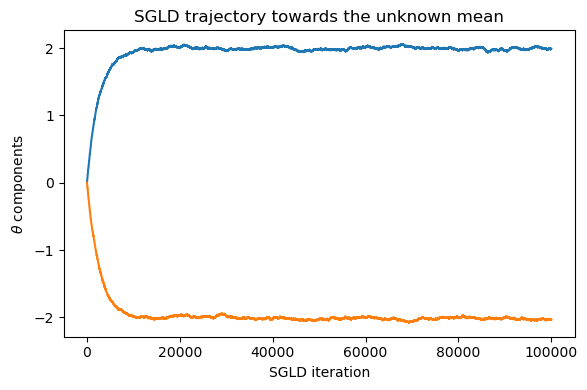

In [17]:
d = 2
mu_unknown = np.array([2, -2])
sigma_known = np.array([1, 1])

N = 100_000
X_data_normal = np.random.normal(mu_unknown, sigma_known, (N, d))

# SGLD hyperparameters
theta_0 = np.zeros(d)
beta = 1e6       # inverse temperature - large beta -> SGLD behaves close to SGD
lambda_ = 0.001  # step size
N_sgld = 100_000
t_0_sgld = 0
T_sgld = 1

theta_hat, theta_tracker = fct.thetahat_func(
    X_data=X_data_normal, beta=beta, lambda_=lambda_,
    theta_0=theta_0, N_sgld=N_sgld, t_0=t_0_sgld, T=T_sgld
)

print("theta_hat (SGLD estimate of mu):", theta_hat)
print("True mu:                        ", mu_unknown)

plt.figure(figsize=(6, 4))
plt.plot(theta_tracker)
plt.xlabel("SGLD iteration")
plt.ylabel(r"$\theta$ components")
plt.title("SGLD trajectory towards the unknown mean")
plt.tight_layout()
plt.show()

Single sample: [ 0.93445866 -1.31442082]


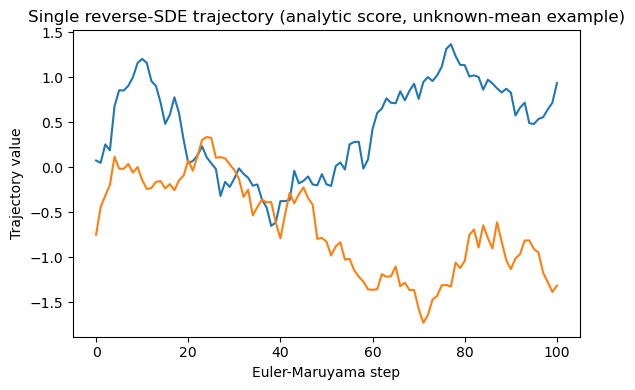

In [18]:
# ------------------------------------------------------------
# Single-trajectory check: plug theta_hat into the analytic-score
# reverse SDE and confirm the path looks sensible.
# ------------------------------------------------------------
sample, path = fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.01, T=1, d=2)
print("Single sample:", sample)

plt.figure(figsize=(6, 4))
plt.plot(path)
plt.xlabel("Euler-Maruyama step")
plt.ylabel("Trajectory value")
plt.title("Single reverse-SDE trajectory (analytic score, unknown-mean example)")
plt.tight_layout()
plt.show()

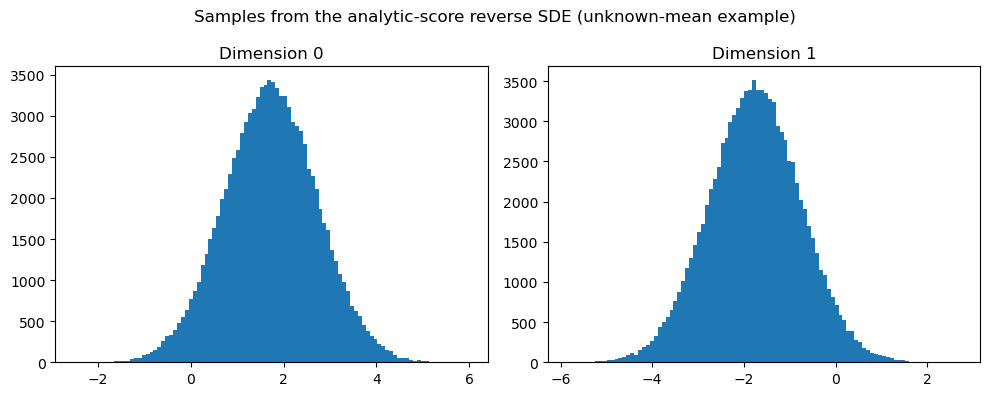

In [ ]:
# Distributional check: many independent reverse-SDE draws should
N_samples = 100_000
samples_analytic = np.array([
    fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.001, T=1, d=2)[0]
    for _ in range(N_samples)
])

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_analytic[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Samples from the analytic-score reverse SDE (unknown-mean example)")
plt.tight_layout()
plt.show()

iter 0, loss = 12.0047
iter 500, loss = 3.3158
iter 1000, loss = 2.6203
iter 1500, loss = 1.8727
iter 2000, loss = 1.6596
iter 2500, loss = 2.9930
iter 3000, loss = 4.2388
iter 3500, loss = 1.7312
iter 4000, loss = 4.1630
iter 4500, loss = 3.0010
NN sample mean: [ 1.7473471  -1.70973171]
True mu:        [ 2 -2]


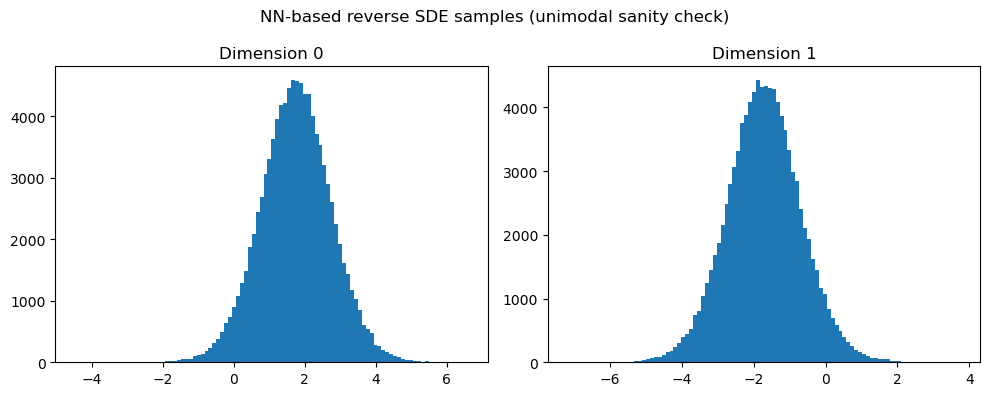

In [20]:
D_1_normal = 32
net_normal = fct.ScoreNet(d=d, D_1=D_1_normal)

net_normal = fct.train_score_net(
    net_normal, X_data_normal, t_0=0, T=1, d=d,
    n_iters=5000, batch_size=256, lr=1e-3, device=device
)

samples_nn_normal = fct.euler_maruyama_sample_nn_batch(
    net_normal, gamma=0.001, T=1, d=d, N_samples=100_000, device=device
)

print("NN sample mean:", samples_nn_normal.mean(axis=0))
print("True mu:       ", mu_unknown)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_nn_normal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("NN-based reverse SDE samples (unimodal sanity check)")
plt.tight_layout()
plt.show()

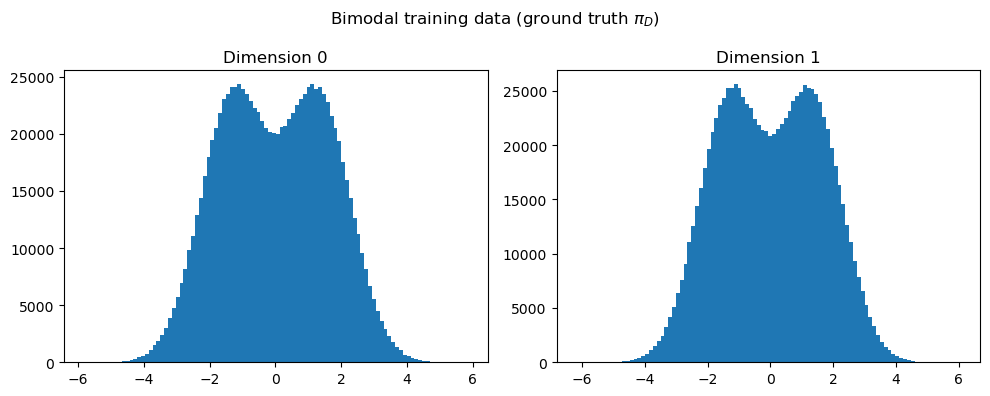

In [15]:
# Visibly separable bimodal example. 
d = 2
mu1 = np.array([1.3, 1.3])
mu2 = np.array([-1.3, -1.3])
weight = 0.5
sigma_mix = 1.0

N_bimodal = 1_000_000
X_data_bimodal = fct.sample_bimodal_data(
    N=N_bimodal, d=d, mu1=mu1, mu2=mu2, sigma=sigma_mix, weight=weight
)

true_mixture_mean = weight * mu1 + (1 - weight) * mu2

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal training data (ground truth $\\pi_D$)")
plt.tight_layout()
plt.show()

iter 0, loss = 2.8138
iter 500, loss = 3.6421
iter 1000, loss = 2.7073
iter 1500, loss = 3.2523
iter 2000, loss = 3.1329
iter 2500, loss = 2.6845
iter 3000, loss = 3.7207
iter 3500, loss = 3.7030
iter 4000, loss = 3.0194
iter 4500, loss = 3.0681
iter 5000, loss = 4.4548
iter 5500, loss = 2.7663
iter 6000, loss = 3.5284
iter 6500, loss = 4.5715
iter 7000, loss = 3.1126
iter 7500, loss = 3.2849
iter 8000, loss = 2.9408
iter 8500, loss = 5.4789
iter 9000, loss = 3.9251
iter 9500, loss = 3.1340
2-layer NN sample mean: [0.01833557 0.05483773]
True mixture mean:      [0. 0.]


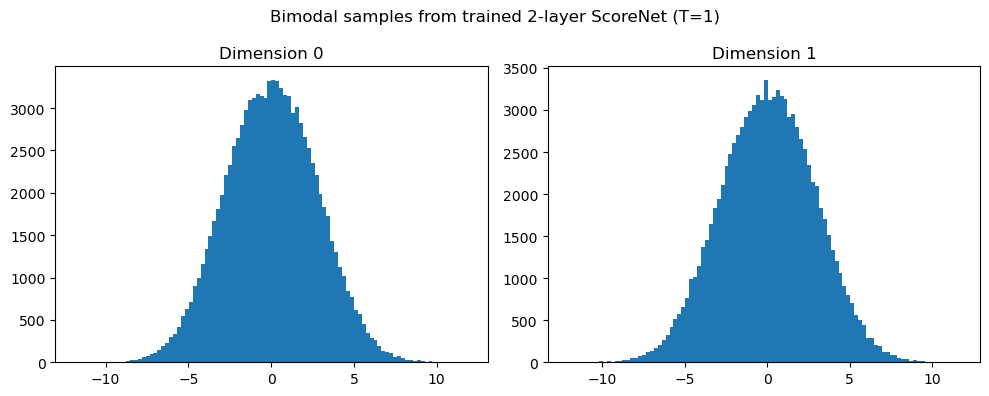

In [7]:
# ------------------------------------------------------------
# Train the 2-layer ScoreNet on the bimodal mixture at T = 1.
# ------------------------------------------------------------
D_1_bimodal = 128

net_bimodal = fct.ScoreNet(d=d, D_1=D_1_bimodal)
net_bimodal = fct.train_score_net(
    net_bimodal, X_data_bimodal, t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3, device=device
)

samples_bimodal_2layer = fct.euler_maruyama_sample_nn_batch(
    net_bimodal, gamma=0.001, T=1, d=d, N_samples=100_000, device=device
)

print("2-layer NN sample mean:", samples_bimodal_2layer.mean(axis=0))
print("True mixture mean:     ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal_2layer[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal samples from trained 2-layer ScoreNet (T=1)")
plt.tight_layout()
plt.show()

iter 0, loss = 3.7724
iter 500, loss = 4.0374
iter 1000, loss = 2.8602
iter 1500, loss = 4.7353
iter 2000, loss = 3.5307
iter 2500, loss = 3.1916
iter 3000, loss = 3.2715
iter 3500, loss = 3.6001
iter 4000, loss = 3.3172
iter 4500, loss = 5.1093
iter 5000, loss = 3.9252
iter 5500, loss = 3.3650
iter 6000, loss = 2.8706
iter 6500, loss = 2.8515
iter 7000, loss = 4.3954
iter 7500, loss = 3.8625
iter 8000, loss = 4.0604
iter 8500, loss = 5.0606
iter 9000, loss = 3.9743
iter 9500, loss = 3.4736
3-layer NN sample mean: [-0.11506361 -0.02492686]
True mixture mean:      [0. 0.]


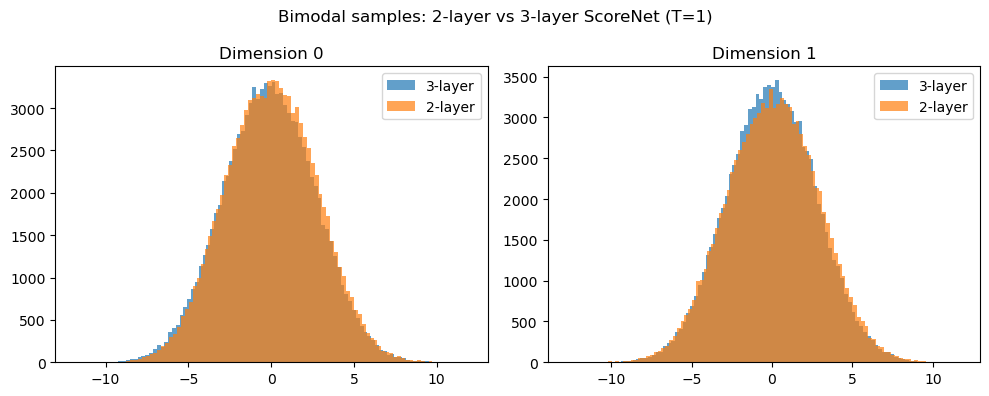

In [8]:
# ------------------------------------------------------------
# Train ScoreNet3 (3-layer) on the same data, for direct comparison.
# ------------------------------------------------------------
D_1_bimodal_3 = 128
D_2_bimodal_3 = 128

net_bimodal_3 = fct.ScoreNet3(d=d, D_1=D_1_bimodal_3, D_2=D_2_bimodal_3)
net_bimodal_3 = fct.train_score_net(
    net_bimodal_3, X_data_bimodal, t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3, device=device
)

samples_bimodal_3layer = fct.euler_maruyama_sample_nn_batch(
    net_bimodal_3, gamma=0.001, T=1, d=d, N_samples=100_000, device=device
)

print("3-layer NN sample mean:", samples_bimodal_3layer.mean(axis=0))
print("True mixture mean:     ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal_3layer[:, i], bins=100, alpha=0.7, label="3-layer")
    axes[i].hist(samples_bimodal_2layer[:, i], bins=100, alpha=0.7, label="2-layer")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle("Bimodal samples: 2-layer vs 3-layer ScoreNet (T=1)")
plt.tight_layout()
plt.show()

In [9]:
# ------------------------------------------------------------
# Quick numerical sanity check on the mixture parameters vs the data.
# ------------------------------------------------------------
print("mu1:", mu1, " mu2:", mu2, " weight:", weight)
print("X_data_bimodal mean per dim:", X_data_bimodal.mean(axis=0))
print("X_data_bimodal std per dim: ", X_data_bimodal.std(axis=0))

mu1: [2. 2.]  mu2: [-2. -2.]  weight: 0.5
X_data_bimodal mean per dim: [0.00684364 0.00896733]
X_data_bimodal std per dim:  [3.60545289 3.60580571]


In [10]:
N_w2_snapshot = 5000

# NOTE: for a strictly clean train/eval split, draw a fresh independent
# batch via fct.sample_bimodal_data(...) instead of slicing X_data_bimodal,
# since the networks above trained on random indices from the full array.
samples_true_snapshot = X_data_bimodal[:N_w2_snapshot]
samples_2layer_snapshot = samples_bimodal_2layer[:N_w2_snapshot]
samples_3layer_snapshot = samples_bimodal_3layer[:N_w2_snapshot]

a = np.ones(N_w2_snapshot) / N_w2_snapshot
b = np.ones(N_w2_snapshot) / N_w2_snapshot

M_2layer = ot.dist(samples_2layer_snapshot, samples_true_snapshot, metric='sqeuclidean')
M_3layer = ot.dist(samples_3layer_snapshot, samples_true_snapshot, metric='sqeuclidean')

W2_2layer_snapshot = np.sqrt(ot.emd2(a, b, M_2layer, numItermax=1_000_000))
W2_3layer_snapshot = np.sqrt(ot.emd2(a, b, M_3layer, numItermax=1_000_000))

print(f"W2 (2-layer ScoreNet, N={N_w2_snapshot}): {W2_2layer_snapshot:.4f}")
print(f"W2 (3-layer ScoreNet, N={N_w2_snapshot}): {W2_3layer_snapshot:.4f}")

W2 (2-layer ScoreNet, N=5000): 1.2354
W2 (3-layer ScoreNet, N=5000): 1.3308


In [11]:
# ------------------------------------------------------------
# Noise floor at a single N: W_2 between two INDEPENDENT samples both
# drawn from pi_D. Not zero at finite N - this is the estimator's own bias.
# ------------------------------------------------------------
N_floor_check = 5000
samples_true_a = X_data_bimodal[:N_floor_check]
samples_true_b = X_data_bimodal[N_floor_check:2 * N_floor_check]

a = np.ones(N_floor_check) / N_floor_check
b = np.ones(N_floor_check) / N_floor_check

M_floor = ot.dist(samples_true_a, samples_true_b, metric='sqeuclidean')
W2_floor_5000 = np.sqrt(ot.emd2(a, b, M_floor, numItermax=1_000_000))
print(f"W2 between two independent samples of pi_D (N={N_floor_check}): {W2_floor_5000:.4f}")

W2 between two independent samples of pi_D (N=5000): 0.3491


i find that the curves for both the 3 layer neural net and the 2 layer neural net in non monotone decreasing. This means that there could be a computational ceiling on how well this implementation fits the data. 

N =   100: noise floor = 1.5967 ± 0.0896
N =   250: noise floor = 1.1543 ± 0.0799
N =   500: noise floor = 0.9276 ± 0.1038
N =  1000: noise floor = 0.6754 ± 0.0597
N =  2000: noise floor = 0.5120 ± 0.0373
N =  3000: noise floor = 0.4386 ± 0.0470
N =  5000: noise floor = 0.3356 ± 0.0188


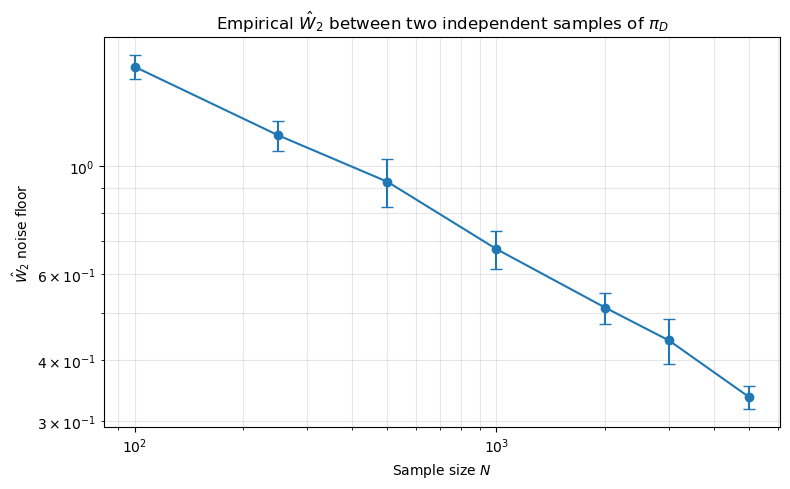

In [12]:
# ------------------------------------------------------------
# Noise floor as a function of N. Lets us look up the floor at whatever
# N we use later (e.g. N=2000 in the T-sweep, Section 6).
# ------------------------------------------------------------
def W2_self_floor(X_data, N, n_repeats=5):
    """
    Estimate the W_2 noise floor at sample size N by computing W_2
    between two independent draws from X_data, averaged over n_repeats
    to reduce Monte Carlo variance in the estimate itself.
    """
    W2_vals = []
    a = np.ones(N) / N
    b = np.ones(N) / N
    for _ in range(n_repeats):
        idx = np.random.permutation(len(X_data))
        s1 = X_data[idx[:N]]
        s2 = X_data[idx[N:2 * N]]
        M = ot.dist(s1, s2, metric='sqeuclidean')
        W2_vals.append(np.sqrt(ot.emd2(a, b, M, numItermax=10_000_000)))
    return np.mean(W2_vals), np.std(W2_vals)


sample_sizes = [100, 250, 500, 1000, 2000, 3000, 5000]
floors, floor_stds = [], []

for N in sample_sizes:
    mean, std = W2_self_floor(X_data_bimodal, N, n_repeats=5)
    floors.append(mean)
    floor_stds.append(std)
    print(f"N = {N:5d}: noise floor = {mean:.4f} ± {std:.4f}")

W2_floor_by_N = dict(zip(sample_sizes, floors))  # lookup table for later sections

plt.figure(figsize=(8, 5))
plt.errorbar(sample_sizes, floors, yerr=floor_stds, marker='o', capsize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample size $N$')
plt.ylabel(r'$\hat{W}_2$ noise floor')
plt.title(r'Empirical $\hat{W}_2$ between two independent samples of $\pi_D$')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

We cannot improve the distance between the distribution here by increasing the number training iterations. THe $\epsilon_{SN}$ is the error of the network estimated score. 


$$\varepsilon_{SN} = \int_\epsilon^T \frac{\kappa(t)}{T - \epsilon} \int_{\mathbb{R}^d} \bigl|\nabla_x \log p_t(x) - s(t, \hat{\theta}, x)\bigr|^2 p_t(x)\, dx\, dt.$$

Checkpoint 20...
  W2 2-layer: 1.7032 ± 0.0000 | W2 3-layer: 1.5609 ± 0.0000
Checkpoint 50...
  W2 2-layer: 1.3262 ± 0.0000 | W2 3-layer: 1.4578 ± 0.0000
Checkpoint 100...
  W2 2-layer: 1.4840 ± 0.0000 | W2 3-layer: 1.5262 ± 0.0000
Checkpoint 250...
  W2 2-layer: 1.5714 ± 0.0000 | W2 3-layer: 1.3064 ± 0.0000
Checkpoint 500...
  W2 2-layer: 1.4489 ± 0.0000 | W2 3-layer: 1.4060 ± 0.0000
Checkpoint 1000...
  W2 2-layer: 1.4736 ± 0.0000 | W2 3-layer: 1.6740 ± 0.0000
Checkpoint 2000...
  W2 2-layer: 1.5645 ± 0.0000 | W2 3-layer: 1.5252 ± 0.0000
Checkpoint 3000...
  W2 2-layer: 1.3067 ± 0.0000 | W2 3-layer: 1.4144 ± 0.0000
Checkpoint 5000...
  W2 2-layer: 1.1797 ± 0.0000 | W2 3-layer: 1.4220 ± 0.0000


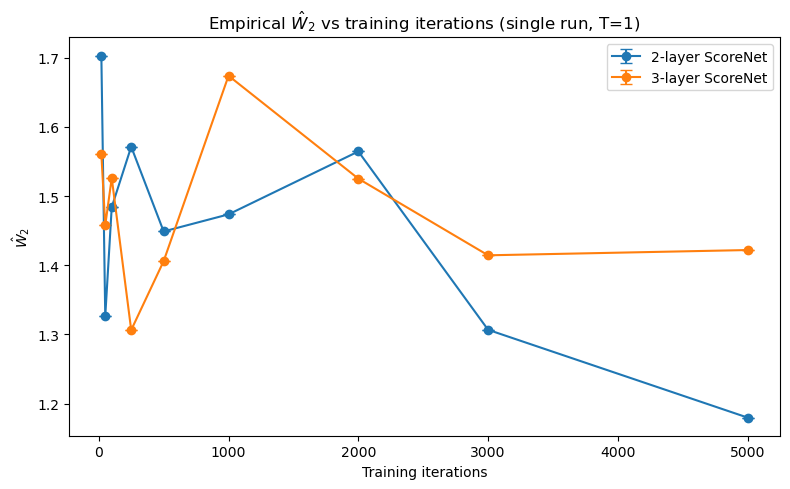

In [13]:
checkpoints = [20, 50, 100, 250, 500, 1000, 2000, 3000,  5000]

# Quick single-run sanity check before the expensive multi-repeat version.
results_T1_single = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=1, T=1
)
fct.plot_W2_curve(results_T1_single, title_suffix="(single run, T=1)")

This reduction in loss can be explained by the $C_2$ term in the error bound. 

$e^{-2\hat{L}_{\mathrm{MO}}(T - \epsilon) - \epsilon}$

The larger T increases the negative exponent on the exponential multiplying the bound on $C_2$ constant. It seems as though there is a sweetspot for the choice of T.  

Checkpoint 20...
  W2 2-layer: 1.7266 ± 0.0397 | W2 3-layer: 1.2460 ± 0.0715
Checkpoint 50...
  W2 2-layer: 1.2601 ± 0.0421 | W2 3-layer: 1.6895 ± 0.0370
Checkpoint 100...
  W2 2-layer: 1.4112 ± 0.0159 | W2 3-layer: 1.7799 ± 0.0464
Checkpoint 250...
  W2 2-layer: 1.1734 ± 0.0478 | W2 3-layer: 1.3310 ± 0.0491
Checkpoint 500...
  W2 2-layer: 1.5970 ± 0.0357 | W2 3-layer: 1.4915 ± 0.0432
Checkpoint 1000...
  W2 2-layer: 1.5113 ± 0.0401 | W2 3-layer: 1.1896 ± 0.0279
Checkpoint 2000...
  W2 2-layer: 1.3939 ± 0.0491 | W2 3-layer: 1.3582 ± 0.0505
Checkpoint 3000...
  W2 2-layer: 1.4101 ± 0.0552 | W2 3-layer: 1.3677 ± 0.0434
Checkpoint 5000...
  W2 2-layer: 1.3838 ± 0.0135 | W2 3-layer: 1.3305 ± 0.0214


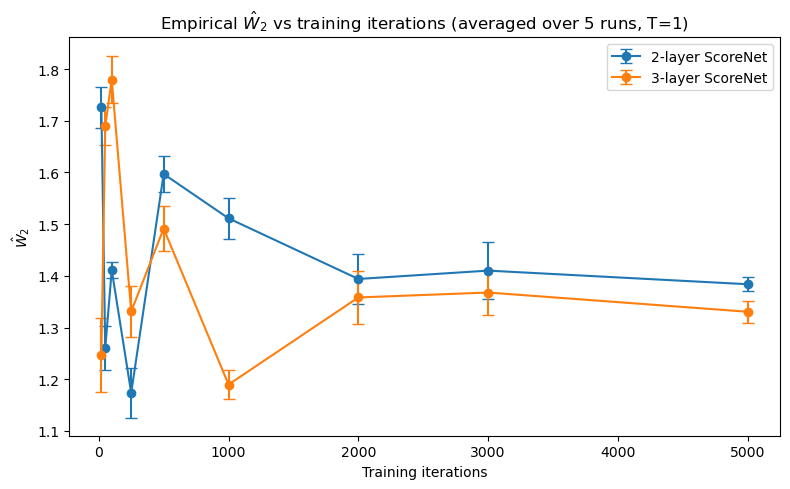

In [14]:
# Averaged (5 repeats), T=1: expect a plateau once initialisation error dominates.
results_T1 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=1
)
fct.plot_W2_curve(results_T1, title_suffix="(averaged over 5 runs, T=1)")

Checkpoint 20...
  W2 2-layer: 1.6303 ± 0.0544 | W2 3-layer: 2.6408 ± 0.0914
Checkpoint 50...
  W2 2-layer: 1.9433 ± 0.0981 | W2 3-layer: 2.7242 ± 0.1270
Checkpoint 100...
  W2 2-layer: 1.9159 ± 0.0583 | W2 3-layer: 1.9474 ± 0.0362
Checkpoint 250...
  W2 2-layer: 2.0275 ± 0.0654 | W2 3-layer: 1.3844 ± 0.0926
Checkpoint 500...
  W2 2-layer: 1.6477 ± 0.1056 | W2 3-layer: 1.1459 ± 0.0868
Checkpoint 1000...
  W2 2-layer: 1.1763 ± 0.1323 | W2 3-layer: 0.9617 ± 0.0359
Checkpoint 2000...
  W2 2-layer: 0.7312 ± 0.0438 | W2 3-layer: 1.0697 ± 0.0709
Checkpoint 3000...
  W2 2-layer: 0.7755 ± 0.0493 | W2 3-layer: 0.7864 ± 0.0560
Checkpoint 5000...
  W2 2-layer: 0.6138 ± 0.0421 | W2 3-layer: 0.9134 ± 0.0539


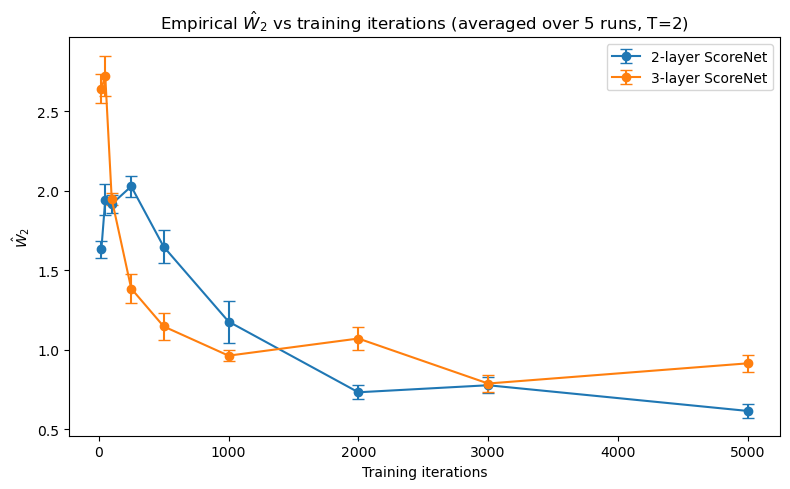

In [15]:
# T=2: term 2 (initialisation error) decays in T, so expect a lower floor than T=1.
results_T2 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2
)
fct.plot_W2_curve(results_T2, title_suffix="(averaged over 5 runs, T=2)")

Checkpoint 20...
  W2 2-layer: 8.8198 ± 0.1513 | W2 3-layer: 6.9969 ± 0.2436
Checkpoint 50...
  W2 2-layer: 7.0287 ± 0.2432 | W2 3-layer: 7.2603 ± 0.4056
Checkpoint 100...
  W2 2-layer: 6.0143 ± 0.3869 | W2 3-layer: 6.8267 ± 0.3553
Checkpoint 250...
  W2 2-layer: 5.5777 ± 0.1471 | W2 3-layer: 3.8610 ± 0.2000
Checkpoint 500...
  W2 2-layer: 3.7840 ± 0.0936 | W2 3-layer: 2.0978 ± 0.1182
Checkpoint 1000...
  W2 2-layer: 1.8802 ± 0.2126 | W2 3-layer: 1.5515 ± 0.1020
Checkpoint 2000...
  W2 2-layer: 1.0671 ± 0.1598 | W2 3-layer: 0.9945 ± 0.1272
Checkpoint 3000...
  W2 2-layer: 0.8546 ± 0.0368 | W2 3-layer: 0.7471 ± 0.0383
Checkpoint 5000...
  W2 2-layer: 0.6588 ± 0.0731 | W2 3-layer: 0.8093 ± 0.0519


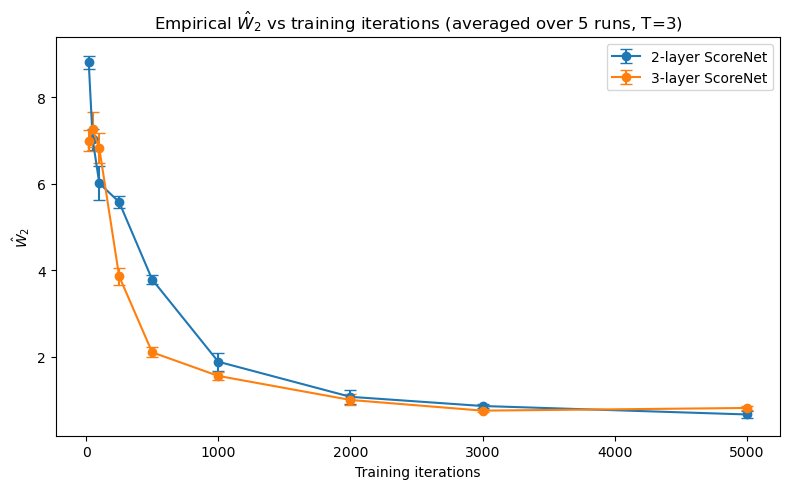

In [16]:
# T=3, default N_w2. Kept distinct from the N_w2=10000 version in Section 7.
results_T3 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3
)
fct.plot_W2_curve(results_T3, title_suffix="(averaged over 5 runs, T=3)")

In [17]:
print('s')

s


Checkpoint 20...
  W2 2-layer: 7.1476 ± 0.1045 | W2 3-layer: 8.4488 ± 0.0393
Checkpoint 50...
  W2 2-layer: 8.1006 ± 0.0524 | W2 3-layer: 6.5233 ± 0.0827
Checkpoint 100...
  W2 2-layer: 7.4343 ± 0.0949 | W2 3-layer: 6.8748 ± 0.1031
Checkpoint 250...
  W2 2-layer: 6.0882 ± 0.1482 | W2 3-layer: 3.7325 ± 0.0711
Checkpoint 500...
  W2 2-layer: 3.6599 ± 0.0749 | W2 3-layer: 1.2924 ± 0.0594
Checkpoint 1000...
  W2 2-layer: 1.4672 ± 0.0617 | W2 3-layer: 1.4855 ± 0.0664
Checkpoint 2000...
  W2 2-layer: 0.8389 ± 0.0978 | W2 3-layer: 0.8212 ± 0.0111
Checkpoint 3000...
  W2 2-layer: 0.6293 ± 0.0545 | W2 3-layer: 0.5371 ± 0.0199
Checkpoint 5000...
  W2 2-layer: 0.5908 ± 0.0324 | W2 3-layer: 0.6613 ± 0.0385


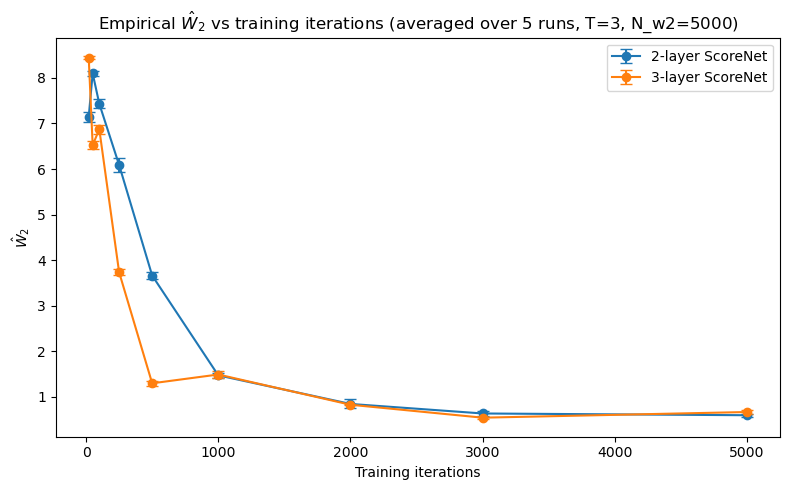

: 

In [ ]:
results_T3_N5000 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3, N_w2=10_000
)
fct.plot_W2_curve(results_T3_N5000, title_suffix="(averaged over 5 runs, T=3, N_w2=5000)")

In [ ]:
checkpoints = [20, 50, 100, 250, 500, 1000, 2000, 3000,  5000]

results_single1000 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=1, T=1000
)

fct.plot_W2_curve(results_single1000, title_suffix="(single run, T=1000)")

Checkpoint 20...


In [ ]:
results_T2_N5000 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2, N_w2=10_000
)
fct.plot_W2_curve(results_T2_N5000, title_suffix="(averaged over 5 runs, T=2, N_w2=5000)")

Checkpoint 100...


KeyboardInterrupt: 

Checkpoint 1000...
  W2 2-layer: 1.9840 ± 0.0834 | W2 3-layer: 1.4757 ± 0.0339
Checkpoint 2000...
  W2 2-layer: 0.8042 ± 0.0188 | W2 3-layer: 0.7106 ± 0.0292
Checkpoint 5000...
  W2 2-layer: 0.5727 ± 0.0100 | W2 3-layer: 0.7034 ± 0.0259
Checkpoint 10000...
  W2 2-layer: 0.4680 ± 0.0381 | W2 3-layer: 0.5026 ± 0.0322
Checkpoint 20000...
  W2 2-layer: 0.7586 ± 0.0394 | W2 3-layer: 0.4650 ± 0.0217


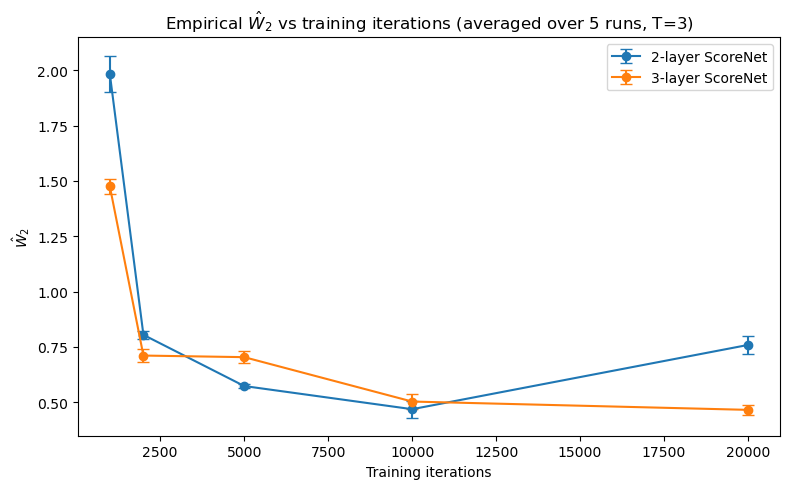

In [ ]:
results_T3 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3, N_w2= 5000
)

fct.plot_W2_curve(results_T3, title_suffix="(averaged over 5 runs, T=3)")

Checkpoint 1000...
  W2 2-layer: 0.9384 ± 0.0527 | W2 3-layer: 0.8864 ± 0.0332
Checkpoint 2000...
  W2 2-layer: 0.5107 ± 0.0290 | W2 3-layer: 0.7465 ± 0.0207
Checkpoint 5000...
  W2 2-layer: 0.4782 ± 0.0162 | W2 3-layer: 0.5323 ± 0.0171
Checkpoint 10000...
  W2 2-layer: 0.6625 ± 0.0335 | W2 3-layer: 0.3510 ± 0.0212
Checkpoint 20000...
  W2 2-layer: 0.4327 ± 0.0097 | W2 3-layer: 0.6452 ± 0.0192


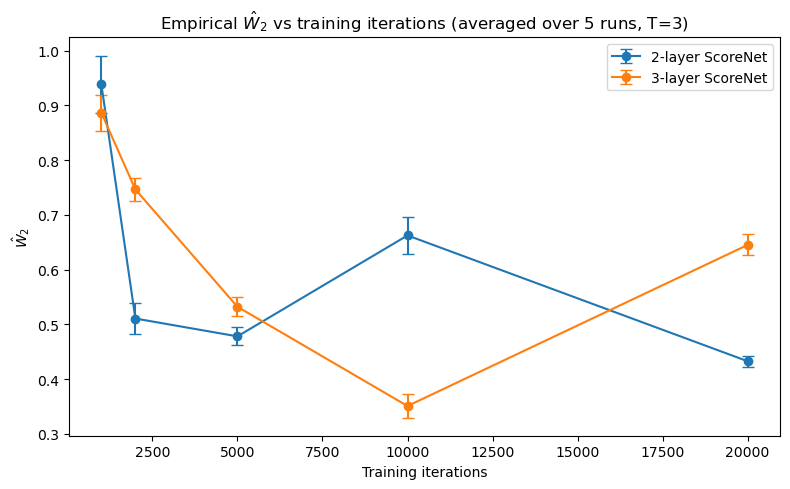

In [ ]:
results_T4 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2, N_w2= 10_000
)

fct.plot_W2_curve(results_T4, title_suffix="(averaged over 5 runs, T=3)")